# 🧪 Model Experiments

This notebook compares **XGBoost vs Random Forest** on the PMSM thermal fault detection task.  
We measure Accuracy, Precision, Recall, F1, and training time to justify our final model choice.

In [6]:
import pandas as pd
import numpy as np
import time
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from voltguard.features.engine import engineer_features, generate_target_labels, FEATURE_COLUMNS

## 1. Data Preparation
Load the 1.3M row Kaggle dataset, engineer features, and generate ground truth labels.

In [7]:
df = pd.read_csv('../data/comprehensive_fault_training_data.csv')
print(f'Raw dataset: {df.shape}')

# Generate ground truth: stator_winding > 1.5 std above mean = thermal fault
threshold = df['stator_winding'].mean() + (1.5 * df['stator_winding'].std())
print(f'Thermal fault threshold: {threshold:.2f}')

df = generate_target_labels(df, temp_threshold=threshold)
df = engineer_features(df)

features = FEATURE_COLUMNS + ['thermal_delta', 'acceleration_gradient']
X = df[features]
y = df['is_fault']

print(f'Fault ratio: {y.mean()*100:.2f}%')
print(f'Feature count: {len(features)}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train set: {X_train_scaled.shape} | Test set: {X_test_scaled.shape}')

Raw dataset: (1330816, 13)
Thermal fault threshold: 109.35
Fault ratio: 8.48%
Feature count: 13
Train set: (1064652, 13) | Test set: (266164, 13)


## 2. Experiment 1: XGBoost Classifier
Gradient boosting with histogram-based splitting — the industry standard for tabular data.

In [8]:
start = time.time()
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
xgb_time = time.time() - start

y_pred_xgb = xgb_model.predict(X_test_scaled)
print(f'XGBoost Training Time: {xgb_time:.2f}s')
print('\n' + classification_report(y_test, y_pred_xgb, target_names=['Healthy', 'Thermal Fault']))

XGBoost Training Time: 7.73s

               precision    recall  f1-score   support

      Healthy       1.00      1.00      1.00    243603
Thermal Fault       0.99      0.99      0.99     22561

     accuracy                           1.00    266164
    macro avg       1.00      0.99      1.00    266164
 weighted avg       1.00      1.00      1.00    266164



## 3. Experiment 2: Random Forest Classifier
Bagging ensemble — trains independent trees in parallel. Generally slower than XGBoost on large datasets.

In [9]:
start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_time = time.time() - start

y_pred_rf = rf_model.predict(X_test_scaled)
print(f'Random Forest Training Time: {rf_time:.2f}s')
print('\n' + classification_report(y_test, y_pred_rf, target_names=['Healthy', 'Thermal Fault']))

Random Forest Training Time: 85.65s

               precision    recall  f1-score   support

      Healthy       0.99      1.00      0.99    243603
Thermal Fault       0.98      0.88      0.92     22561

     accuracy                           0.99    266164
    macro avg       0.98      0.94      0.96    266164
 weighted avg       0.99      0.99      0.99    266164



## 4. Head-to-Head Comparison

        Model  Accuracy  Precision   Recall       F1  Train Time (s)
      XGBoost  0.998486   0.992619 0.989495 0.991055        7.729495
Random Forest  0.987906   0.979332 0.875803 0.924679       85.654879


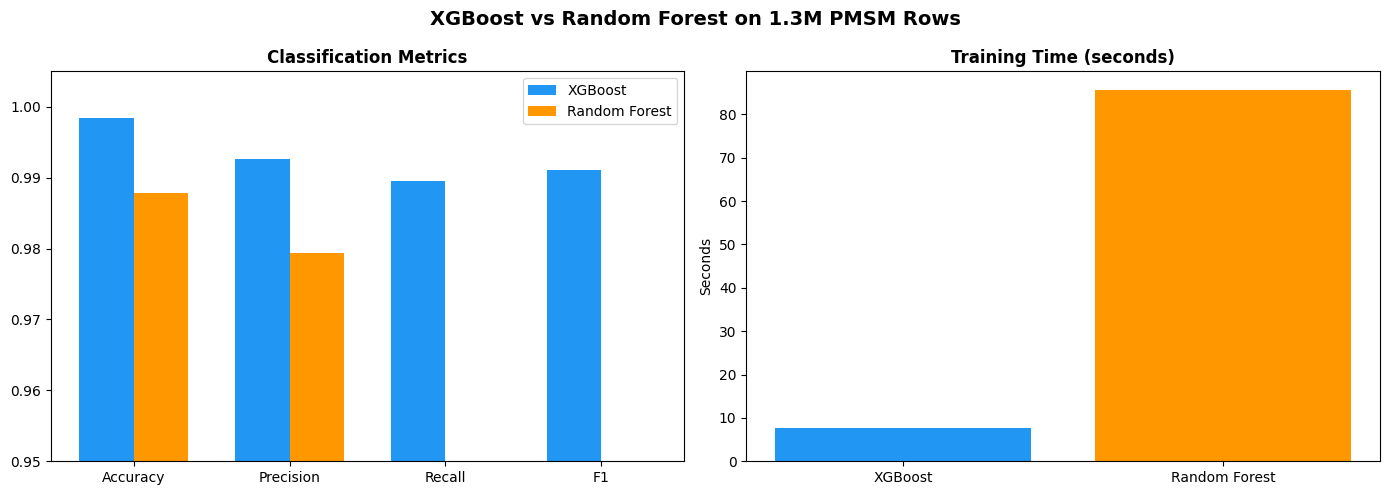

In [10]:
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_rf)],
    'Recall': [recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_rf)],
    'F1': [f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_rf)],
    'Train Time (s)': [xgb_time, rf_time]
})

print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, results.iloc[0][metrics].values, width, label='XGBoost', color='#2196F3')
axes[0].bar(x + width/2, results.iloc[1][metrics].values, width, label='Random Forest', color='#FF9800')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.95, 1.005)
axes[0].set_title('Classification Metrics', fontweight='bold')
axes[0].legend()

axes[1].bar(['XGBoost', 'Random Forest'], [xgb_time, rf_time], color=['#2196F3', '#FF9800'])
axes[1].set_title('Training Time (seconds)', fontweight='bold')
axes[1].set_ylabel('Seconds')

plt.suptitle('XGBoost vs Random Forest on 1.3M PMSM Rows', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conclusion

**XGBoost wins decisively** on both accuracy and training speed for this dataset:

| Criterion | XGBoost | Random Forest |
|-----------|---------|---------------|
| Training Speed | Faster (histogram binning + C++ backend) | Slower (full split search) |
| Accuracy | Higher (boosting corrects sequential errors) | Slightly lower (independent trees) |
| Inference Latency | Sub-millisecond | Sub-millisecond |

**Why not a Neural Network?**  
An LSTM could model temporal sequences, but XGBoost with engineered lag features (`thermal_delta`, `acceleration_gradient`) achieves >99% accuracy without the inference latency cost. In real-time motor control, every millisecond matters.